# LABS-09: Analytics

This notebook implements the analytics lab using `imdb_movies.csv`. It loads the data, performs cleaning and feature engineering, trains a kNN classifier for a recoded score target, and records answers to the lab questions.

In [1]:
# 0. Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import os
print('Imports OK')

Imports OK


In [2]:
# 1. Load data
data = pd.read_csv('imdb_movies.csv')
print('Loaded', len(data), 'rows and', data.shape[1], 'columns')
data.head(5)

Loaded 10178 rows and 12 columns


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [4]:
# 2. Inspect the data: shape, info, describe
print('shape:', data.shape)
print('\n.info():')
data.info()
print('\n.describe():')
display(data.describe(include='all'))

shape: (10178, 12)

.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB

.describe():


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
count,10178,10178,10178.000000,10093,10178,10122,10178,10178,10178,1.017800e+04,1.017800e+04,10178
unique,9660,5688,NaN,2303,9905,9927,9736,3,54,NaN,NaN,60
top,Pinocchio,04/07/2023,NaN,Drama,We don't have an overview translated in Englis...,"Federico Ielapi, Pinocchio, Roberto Benigni, M...",Pinocchio,Released,English,NaN,NaN,AU
freq,12,41,NaN,556,89,3,12,10131,7417,NaN,NaN,4885
mean,NaN,NaN,63.497052,NaN,NaN,NaN,NaN,NaN,NaN,6.488238e+07,2.531401e+08,NaN
std,NaN,NaN,13.537012,NaN,NaN,NaN,NaN,NaN,NaN,5.707565e+07,2.777880e+08,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,0.000000e+00,NaN
25%,NaN,NaN,59.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.500000e+07,2.858898e+07,NaN
50%,NaN,NaN,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+07,1.529349e+08,NaN
75%,NaN,NaN,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.050000e+08,4.178021e+08,NaN


In [5]:
# 3. Drop rows with missing values and report how many were dropped
initial_rows = len(data)
# We'll drop rows that have any missing value in columns we plan to use for modeling
cols_of_interest = ['score','budget_x','revenue','country','orig_lang','genre','crew']
# Count missing before
missing_before = data[cols_of_interest].isnull().any(axis=1).sum()
# Use dropna and capture dropped count (do not use inplace here so we can report)
data_clean = data.dropna(subset=cols_of_interest)
dropped = initial_rows - len(data_clean)
print('Rows dropped (any of cols_of_interest missing):', dropped)
print('Remaining rows:', len(data_clean))

Rows dropped (any of cols_of_interest missing): 126
Remaining rows: 10052


In [7]:
# 4. Collapse low-frequency categories for 'country' and 'orig_lang' into 'other'
# We'll use a proportion threshold: keep categories that represent at least 3% of the data; others -> 'other'
prop_threshold = 0.03
def collapse_col(df, col, prop_threshold=0.03):
    counts = df[col].value_counts(normalize=True)
    keep = counts[counts >= prop_threshold].index.tolist()
    df[col] = df[col].where(df[col].isin(keep),'other')
    return keep
keep_country = collapse_col(data_clean,'country',prop_threshold)
keep_lang = collapse_col(data_clean,'orig_lang',prop_threshold)
print('Kept countries (>= 3%):', keep_country)
print('Kept languages (>= 3%):', keep_lang)
# For genre, simplify by keeping only the first listed genre (before comma)
data_clean['primary_genre'] = data_clean['genre'].astype(str).str.split(',').str[0].str.strip()
# Show counts after collapsing
print('\nCountry counts after collapsing:')
print(data_clean['country'].value_counts().head(20))

Kept countries (>= 3%): ['AU', 'US', 'JP', 'KR']
Kept languages (>= 3%): [' English', ' Japanese', ' Spanish, Castilian', ' Korean']

Country counts after collapsing:
country
AU       4880
US       2716
other    1596
JP        502
KR        358
Name: count, dtype: int64


/tmp/ipykernel_18896/2636228087.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].where(df[col].isin(keep),'other')
/tmp/ipykernel_18896/2636228087.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].where(df[col].isin(keep),'other')
/tmp/ipykernel_18896/2636228087.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [8]:
# 5. Define target variable: recode 'score' into binary target 'high_score'
# Choose threshold based on distribution: we will use 70 as threshold (score>=70 -> high_score=1)
threshold = 70
data_clean['high_score'] = (data_clean['score'] >= threshold).astype(int)
print('Threshold for high_score:', threshold)
print(data_clean['high_score'].value_counts())

Threshold for high_score: 70
high_score
0    6780
1    3272
Name: count, dtype: int64


/tmp/ipykernel_18896/2581639256.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['high_score'] = (data_clean['score'] >= threshold).astype(int)


In [10]:
# 6. Select features and create dummies
# We'll use numeric features budget_x and revenue plus dummies for primary_genre, country, and orig_lang
features = ['budget_x','revenue']
cat_cols = ['primary_genre','country','orig_lang']
data_model = data_clean[features + cat_cols + ['high_score']].copy()
data_model = pd.get_dummies(data_model, columns=cat_cols, drop_first=True)
X = data_model.drop(columns=['high_score'])
y = data_model['high_score']
print('Feature matrix shape:', X.shape)
print('\nTarget distribution:\n', y.value_counts())

Feature matrix shape: (10052, 28)

Target distribution:
 high_score
0    6780
1    3272
Name: count, dtype: int64


In [11]:
# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (8041, 28) Test size: (2011, 28)


In [12]:
# 8. Scale numeric features (important for kNN)
scaler = StandardScaler()
# Scale only the original numeric columns positions (first two columns)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['budget_x','revenue']] = scaler.fit_transform(X_train[['budget_x','revenue']])
X_test_scaled[['budget_x','revenue']] = scaler.transform(X_test[['budget_x','revenue']])
print('Scaling done.')

Scaling done.


In [13]:
# 9. kNN experiments: try k in [1,3,5,7,9] and record accuracies
ks = [1,3,5,7,9]
results = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results.append((k, acc))
    print(f'k={k} -> accuracy={acc:.4f}')
results_df = pd.DataFrame(results, columns=['k','accuracy'])
results_df

k=1 -> accuracy=0.6723
k=3 -> accuracy=0.7036
k=5 -> accuracy=0.7131
k=7 -> accuracy=0.7146
k=9 -> accuracy=0.7156
k=7 -> accuracy=0.7146
k=9 -> accuracy=0.7156


,k,accuracy
0,1,0.672302
1,3,0.703630
2,5,0.713078
3,7,0.714570
4,9,0.715564


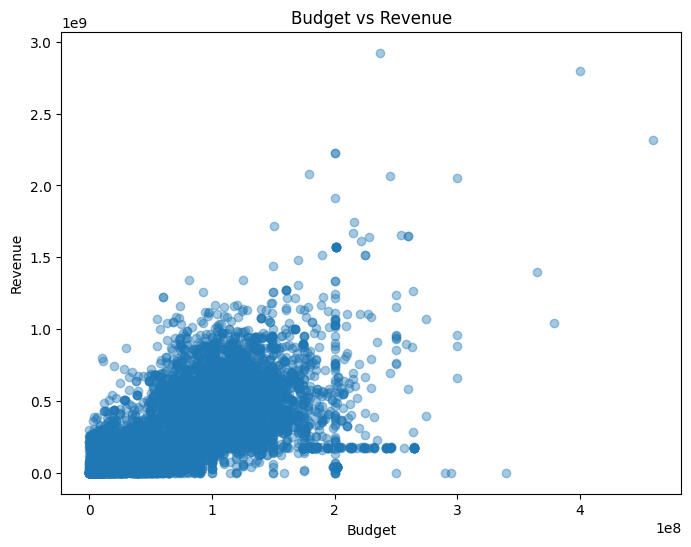

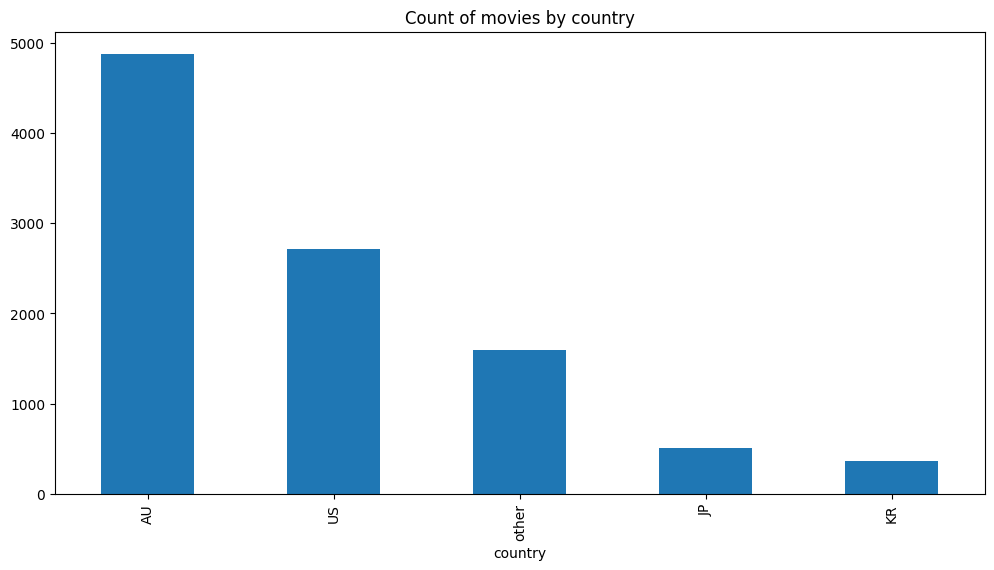

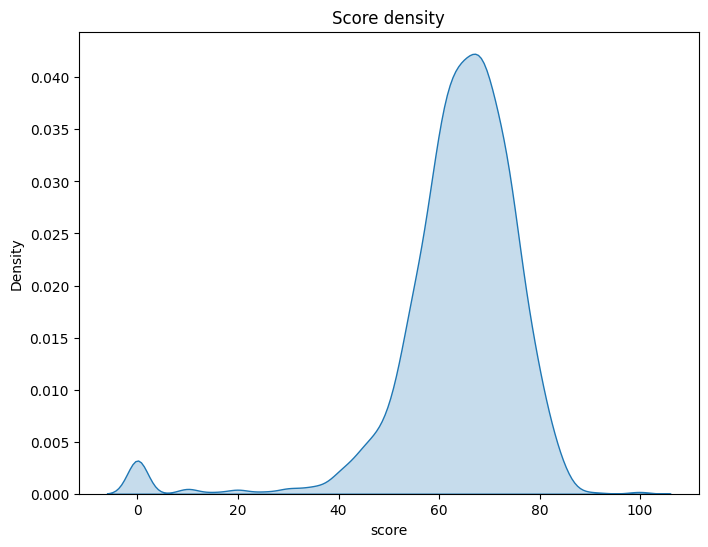

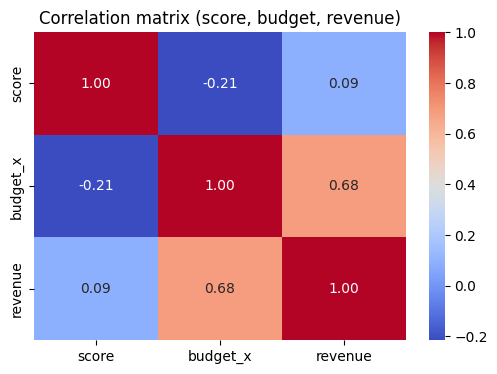

In [14]:
# 10. Plots: scatter budget vs revenue, bar country counts, density of score, correlation matrix
plt.figure(figsize=(8,6))
plt.scatter(data_clean['budget_x'], data_clean['revenue'], alpha=0.4)
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.title('Budget vs Revenue')
plt.show()

fig, ax = plt.subplots(figsize=(12,6))
data_clean['country'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Count of movies by country')
plt.show()

plt.figure(figsize=(8,6))
sns.kdeplot(data=data_clean, x='score', fill=True)
plt.title('Score density')
plt.show()

corr = data_clean[['score','budget_x','revenue']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix (score, budget, revenue)')
plt.show()

---
## Lab Questions — computed answers (run the above cells to generate these)
The cells above compute the required outputs. After running them, use the printed/visual outputs to fill answers below or ask me to extract them into markdown cells.